# Import Libraries

In [2]:
import os
import random
import shutil
import re
from pathlib import Path
from typing import Dict, List, Tuple

import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import applications, callbacks, layers, models


def set_seed(seed: int = 42) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed(42)

# Data Acquisition

In [3]:
dataset_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

original_base_path = os.path.join(dataset_path, 'chest_xray')
if not os.path.exists(original_base_path):
    original_base_path = dataset_path

WORKING_DIR = '/content/chest_xray_working'
if not os.path.exists(WORKING_DIR):
    shutil.copytree(original_base_path, WORKING_DIR, dirs_exist_ok=True)

BASE_PATH = WORKING_DIR
TRAIN_DIR = os.path.join(BASE_PATH, 'train')
VAL_DIR = os.path.join(BASE_PATH, 'val')
TEST_DIR = os.path.join(BASE_PATH, 'test')
CLASSES = ['NORMAL', 'PNEUMONIA']
IMG_EXTENSIONS = {'.jpeg', '.jpg', '.png'}

RESULT_DIR = Path('/content/chest_xray/results')
WEIGHTS_DIR = Path('/content/weights')
for d in [RESULT_DIR, WEIGHTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Working Directory: {BASE_PATH}')

Working Directory: /content/chest_xray_working


# EDA

## Initial Directory Inspection

In [4]:
def check_data_distribution() -> None:
    for split_name, directory in zip(['Train', 'Validation', 'Test'], [TRAIN_DIR, VAL_DIR, TEST_DIR]):
        total = 0
        print(f'{split_name} Set')
        for cls in CLASSES:
            count = len(os.listdir(os.path.join(directory, cls)))
            total += count
            print(f'{cls}: {count} images')
        print(f'Total {split_name}: {total} images\n')


check_data_distribution()

Train Set
NORMAL: 1341 images
PNEUMONIA: 3875 images
Total Train: 5216 images

Validation Set
NORMAL: 8 images
PNEUMONIA: 8 images
Total Validation: 16 images

Test Set
NORMAL: 234 images
PNEUMONIA: 390 images
Total Test: 624 images



## Data Integrity and Channel Check

In [5]:
def check_data_integrity(sample_size: int = 300) -> None:
    corrupted = 0
    channels = set()
    min_pixels, max_pixels = [], []

    for cls in CLASSES:
        cls_dir = os.path.join(TRAIN_DIR, cls)
        files = random.sample(os.listdir(cls_dir), min(sample_size, len(os.listdir(cls_dir))))

        for file in files:
            img = cv2.imread(os.path.join(cls_dir, file), cv2.IMREAD_UNCHANGED)
            if img is None:
                corrupted += 1
                continue
            channels.add(img.shape[2] if len(img.shape) == 3 else 1)
            min_pixels.append(img.min())
            max_pixels.append(img.max())

    print(f'File korup/tidak terbaca : {corrupted} file')
    print(f'Variasi channel warna    : {channels} (1=Grayscale, 3=RGB)')
    print(f'Rentang piksel terendah  : {min(min_pixels)}')
    print(f'Rentang piksel tertinggi : {max(max_pixels)}')


check_data_integrity()

File korup/tidak terbaca : 0 file
Variasi channel warna    : {1, 3} (1=Grayscale, 3=RGB)
Rentang piksel terendah  : 0
Rentang piksel tertinggi : 255


## Class Distribution Visualization

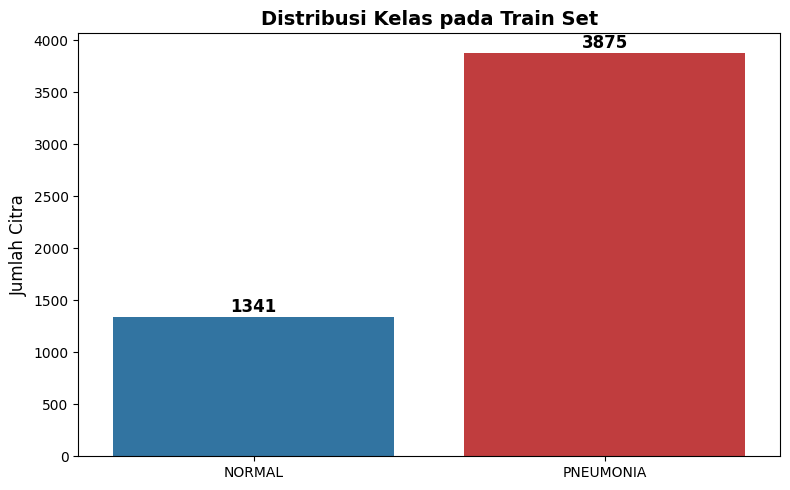

In [6]:
def plot_class_distribution() -> None:
    counts = [len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in CLASSES]

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x=CLASSES, y=counts, hue=CLASSES, palette=['#1f77b4', '#d62728'], legend=False)
    plt.title('Distribusi Kelas pada Train Set', fontsize=14, fontweight='bold')
    plt.ylabel('Jumlah Citra', fontsize=12)
    for i, v in enumerate(counts):
        ax.text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_class_distribution()

## Visual Comparison: Normal vs Pneumonia

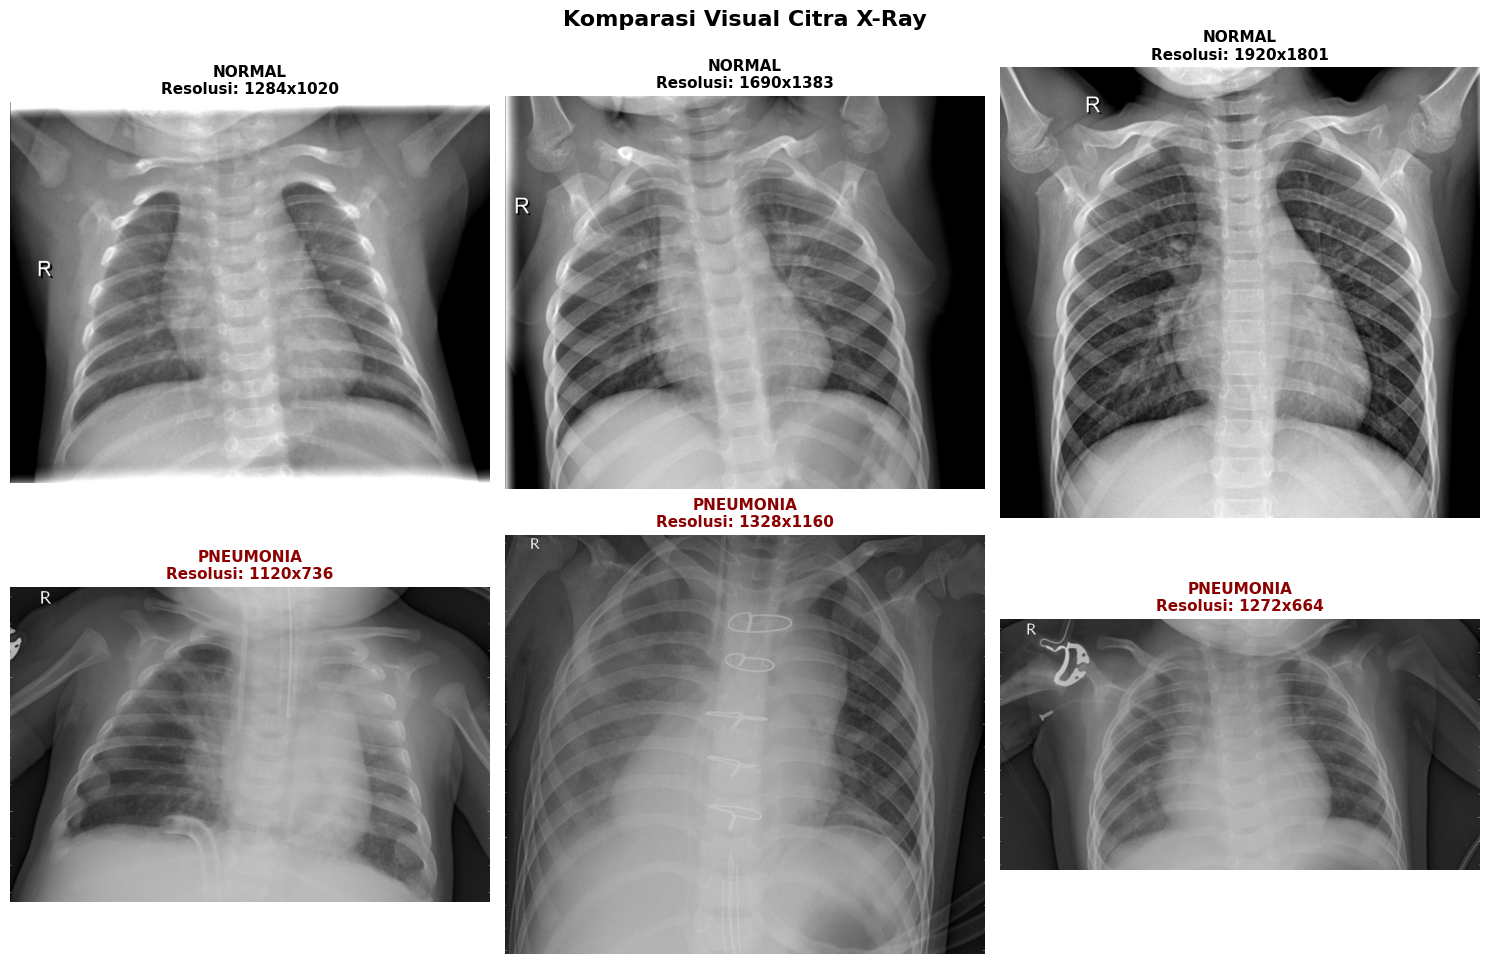

In [7]:
def plot_image_samples() -> None:
    normal_dir = os.path.join(TRAIN_DIR, 'NORMAL')
    pneumonia_dir = os.path.join(TRAIN_DIR, 'PNEUMONIA')
    normal_samples = random.sample(os.listdir(normal_dir), 3)
    pneumonia_samples = random.sample(os.listdir(pneumonia_dir), 3)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for i, img_name in enumerate(normal_samples):
        img = cv2.imread(os.path.join(normal_dir, img_name), cv2.IMREAD_GRAYSCALE)
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f'NORMAL\nResolusi: {img.shape[1]}x{img.shape[0]}', fontweight='bold', fontsize=11)
        axes[0, i].axis('off')
    for i, img_name in enumerate(pneumonia_samples):
        img = cv2.imread(os.path.join(pneumonia_dir, img_name), cv2.IMREAD_GRAYSCALE)
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title(f'PNEUMONIA\nResolusi: {img.shape[1]}x{img.shape[0]}', fontweight='bold', color='darkred', fontsize=11)
        axes[1, i].axis('off')

    plt.suptitle('Komparasi Visual Citra X-Ray', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULT_DIR / 'sample_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_image_samples()

## Visual and Spatial Dimension Analysis

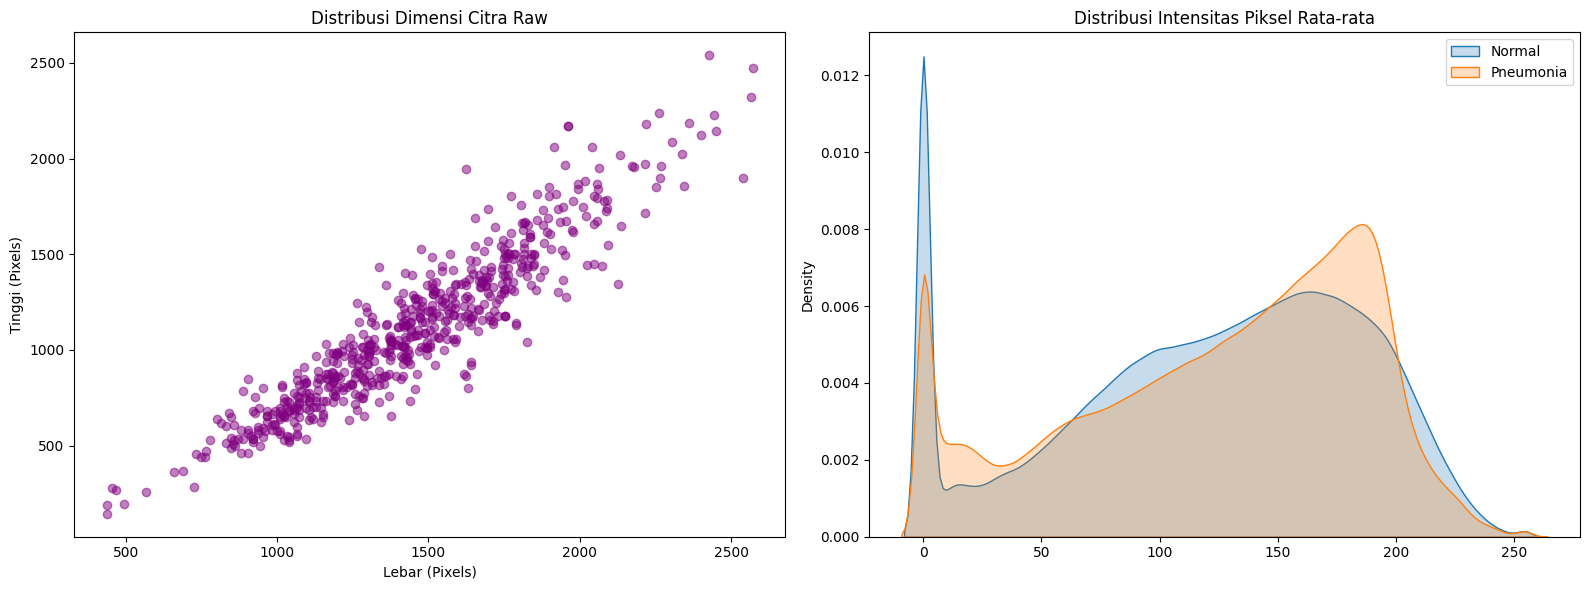

In [8]:
def eda_dimensions_and_pixels(sample_size: int = 300) -> None:
    widths, heights, normal_pixels, pneumo_pixels = [], [], [], []

    for cls_name, pixel_list in zip(CLASSES, [normal_pixels, pneumo_pixels]):
        cls_dir = os.path.join(TRAIN_DIR, cls_name)
        files = random.sample(os.listdir(cls_dir), min(sample_size, len(os.listdir(cls_dir))))
        for file in files:
            img = cv2.imread(os.path.join(cls_dir, file), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                heights.append(img.shape[0])
                widths.append(img.shape[1])
                pixel_list.extend(img.flatten()[::100])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].scatter(widths, heights, alpha=0.5, color='purple')
    axes[0].set_title('Distribusi Dimensi Citra Raw')
    axes[0].set_xlabel('Lebar (Pixels)')
    axes[0].set_ylabel('Tinggi (Pixels)')

    sns.kdeplot(normal_pixels, fill=True, ax=axes[1], label='Normal')
    sns.kdeplot(pneumo_pixels, fill=True, ax=axes[1], label='Pneumonia')
    axes[1].set_title('Distribusi Intensitas Piksel Rata-rata')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(RESULT_DIR / 'dimension_pixel_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()


eda_dimensions_and_pixels()

## Aspect Ratio Distribution

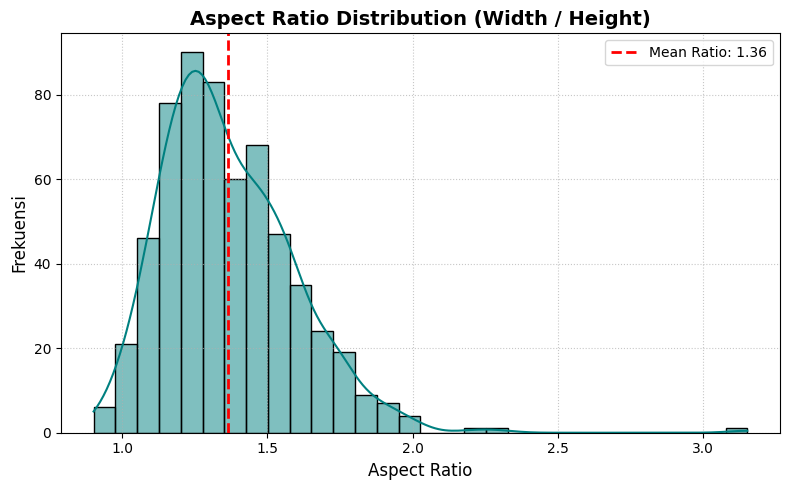

Mean aspect ratio: 1.36


In [9]:
def plot_aspect_ratio(sample_size: int = 300) -> float:
    ratios = []
    for cls in CLASSES:
        cls_dir = os.path.join(TRAIN_DIR, cls)
        files = random.sample(os.listdir(cls_dir), min(sample_size, len(os.listdir(cls_dir))))
        for file in files:
            img = cv2.imread(os.path.join(cls_dir, file), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                h, w = img.shape
                ratios.append(w / h)

    mean_ratio = float(np.mean(ratios))
    plt.figure(figsize=(8, 5))
    sns.histplot(ratios, bins=30, kde=True, color='teal')
    plt.axvline(mean_ratio, color='red', linestyle='dashed', linewidth=2, label=f'Mean Ratio: {mean_ratio:.2f}')
    plt.title('Aspect Ratio Distribution (Width / Height)', fontsize=14, fontweight='bold')
    plt.xlabel('Aspect Ratio', fontsize=12)
    plt.ylabel('Frekuensi', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / 'aspect_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()
    return mean_ratio


mean_aspect_ratio = plot_aspect_ratio()
print(f'Mean aspect ratio: {mean_aspect_ratio:.2f}')

# Data Restructuring and Splitting

## Merging Official Splits

In [10]:
records = []
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        cls_dir = os.path.join(BASE_PATH, split, cls)
        if not os.path.exists(cls_dir):
            continue
        for file in os.listdir(cls_dir):
            if Path(file).suffix.lower() in IMG_EXTENSIONS:
                records.append({'path': os.path.join(cls_dir, file), 'filename': file, 'label': cls})

df_all = pd.DataFrame(records)
print(f'Total gambar: {len(df_all)}')
print(df_all['label'].value_counts())

Total gambar: 5856
label
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64


## Group-Level Split

Gambar PNEUMONIA punya pola nama file `personXXXX_bacteria/virus_YYYY.jpeg` - beberapa gambar berasal dari pasien yang sama. ID pasien diekstrak dari nama file, lalu split dilakukan di level grup pasien - **bukan** per-gambar seperti kebanyakan notebook publik untuk dataset ini. Gambar NORMAL tidak punya pola ID pasien yang jelas, dianggap grup tersendiri per gambar.

In [11]:
def extract_patient_id(filename: str) -> str:
    match = re.match(r'person(\d+)_', filename)
    return f'person{match.group(1)}' if match else filename


df_all['patient_id'] = df_all['filename'].apply(extract_patient_id)
print(f'Total grup (pasien unik + gambar NORMAL tanpa ID): {df_all["patient_id"].nunique()}')

groups = df_all['patient_id'].values

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss_test.split(df_all, groups=groups))
train_val_df = df_all.iloc[train_val_idx].reset_index(drop=True)
test_df = df_all.iloc[test_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15 / 0.85, random_state=42)
train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['patient_id'].values))
train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print(f'train: {len(train_df)}\nval: {len(val_df)}\ntest: {len(test_df)}')

Total grup (pasien unik + gambar NORMAL tanpa ID): 3257
train: 4155
val: 848
test: 853


## Disjointness Verification (runnable check)

Bagian paling penting - harus gagal keras kalau ada pasien yang sama menyebar ke lebih dari satu split.

In [12]:
train_patients = set(train_df['patient_id'])
val_patients = set(val_df['patient_id'])
test_patients = set(test_df['patient_id'])

assert train_patients.isdisjoint(val_patients), 'Data leakage: train/val overlap'
assert train_patients.isdisjoint(test_patients), 'Data leakage: train/test overlap'
assert val_patients.isdisjoint(test_patients), 'Data leakage: val/test overlap'

## Copying Files into Split Directories

In [13]:
SPLIT_DIR = Path('/content/chest_xray_split')
for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    for _, row in split_df.iterrows():
        dst_dir = SPLIT_DIR / split_name / row['label']
        dst_dir.mkdir(parents=True, exist_ok=True)
        dst_path = dst_dir / row['filename']
        if not dst_path.exists():
            shutil.copy(row['path'], dst_path)

for split_name in ['train', 'val', 'test']:
    counts = {cls: len(os.listdir(SPLIT_DIR / split_name / cls)) for cls in CLASSES}
    print(f'{split_name}: {counts}')

train: {'NORMAL': 1082, 'PNEUMONIA': 3073}
val: {'NORMAL': 243, 'PNEUMONIA': 605}
test: {'NORMAL': 258, 'PNEUMONIA': 595}


# Data Preprocessing

In [14]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# PENYESUAIAN BERDASARKAN EDA:
# 1. color_mode='rgb' -> mengatasi variasi dataset yang bercampur grayscale/RGB
# 2. crop_to_aspect_ratio=True -> mencegah distorsi karena mean aspect ratio bukan 1.0

train_dataset = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / 'train', image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary',
    color_mode='rgb', crop_to_aspect_ratio=True, class_names=CLASSES, shuffle=True, seed=42,
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / 'val', image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary',
    color_mode='rgb', crop_to_aspect_ratio=True, class_names=CLASSES, shuffle=False,
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / 'test', image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary',
    color_mode='rgb', crop_to_aspect_ratio=True, class_names=CLASSES, shuffle=False,
)

print(f'Batch training  : {len(train_dataset)} (~{len(train_dataset) * BATCH_SIZE} gambar)')
print(f'Batch validation: {len(val_dataset)} (~{len(val_dataset) * BATCH_SIZE} gambar)')
print(f'Batch test      : {len(test_dataset)} (~{len(test_dataset) * BATCH_SIZE} gambar)')

Found 4155 files belonging to 2 classes.


I0000 00:00:1788957690.252877      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788957690.255679      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 848 files belonging to 2 classes.
Found 853 files belonging to 2 classes.
Batch training  : 130 (~4160 gambar)
Batch validation: 27 (~864 gambar)
Batch test      : 27 (~864 gambar)


## Class Imbalance Handling (Class Weights)

In [15]:
normal_count = sum(1 for _, label in train_dataset.unbatch() if label.numpy() == 0)
pneumonia_count = sum(1 for _, label in train_dataset.unbatch() if label.numpy() == 1)
total_count = normal_count + pneumonia_count

class_weight = {
    0: (1 / normal_count) * (total_count / 2.0),
    1: (1 / pneumonia_count) * (total_count / 2.0),
}

print(f'Distribusi train')
print(f'Normal   : {normal_count}')
print(f'Pneumonia: {pneumonia_count}')
print(f'Class weights: {class_weight}')

Distribusi train
Normal   : 1082
Pneumonia: 3073
Class weights: {0: 1.9200554528650646, 1: 0.6760494630654084}


## On-the-fly Data Augmentation

Augmentasi sebagai Keras layer (bukan `ImageDataGenerator` yang legacy) - jalan di GPU, jadi bagian dari graf model, otomatis nonaktif saat inference/evaluasi.

In [16]:
data_augmentation = tf.keras.Sequential([
    layers.RandomZoom(0.1, seed=42),
    layers.RandomRotation(0.05, seed=42),
    layers.RandomTranslation(0.1, 0.1, seed=42),
], name='data_augmentation_layer')

## I/O Pipeline Optimization

In [17]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# Model Architecture Setup and Callbacks

## Training Callbacks

In [18]:
def get_callbacks(model_name: str):
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(str(WEIGHTS_DIR / f'{model_name}_best.keras'), monitor='val_loss', save_best_only=True),
    ]


EPOCHS_HEAD = 15
METRICS = ['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]

# Model Construction and Training

## Baseline Model: Custom CNN

In [19]:
def build_custom_cnn() -> tf.keras.Model:
    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = layers.Lambda(tf.image.rgb_to_grayscale)(x)  
    x = layers.Rescaling(1. / 255)(x)

    x = layers.Conv2D(32, 3, activation='relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Conv2D(64, 3, activation='relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Conv2D(128, 3, activation='relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs, name='Custom_CNN')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=METRICS)
    return model


model_cnn = build_custom_cnn()
model_cnn.summary()
history_cnn = model_cnn.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS_HEAD,
                             class_weight=class_weight, callbacks=get_callbacks('custom_cnn'))

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_layer         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,672,129 (21.64 MB)

 Trainable params: 5,672,129 (21.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 28s 75ms/step - accuracy: 0.7394 - loss: 0.5275 - precision: 0.8752 - recall: 0.7553 - val_accuracy: 0.7571 - val_loss: 0.5485 - val_precision: 0.9854 - val_recall: 0.6694 - learning_rate: 0.0010
Epoch 2/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.8361 - loss: 0.3659 - precision: 0.9473 - recall: 0.8243 - val_accuracy: 0.7689 - val_loss: 0.4945 - val_precision: 0.9881 - val_recall: 0.6843 - learning_rate: 0.0010
Epoch 3/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.8438 - loss: 0.3389 - precision: 0.9519 - recall: 0.8308 - val_accuracy: 0.8550 - val_loss: 0.3345 - val_precision: 0.9782 - val_recall: 0.8149 - learning_rate: 0.0010
Epoch 4/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.8616 - loss: 0.3290 - precision: 0.9522 - recall: 0.8558 - val_accuracy: 0.8962 - val_loss: 0.2572 - val_precision: 0.9591 - val_recall: 0.8926 - learning_rate: 0.0010
Epoch 5/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accu

## Transfer Learning: DenseNet121 (Feature Extraction)

In [20]:
def build_densenet() -> Tuple[tf.keras.Model, tf.keras.Model]:
    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = applications.densenet.preprocess_input(x)

    base_model = applications.DenseNet121(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs, name='DenseNet121_TL')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=METRICS)
    return model, base_model


model_densenet, base_model_densenet = build_densenet()
model_densenet.summary()
history_densenet = model_densenet.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS_HEAD,
                                       class_weight=class_weight, callbacks=get_callbacks('densenet121'))

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DenseNet121_TL"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation_… │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 224, 224,  │          0 │ data_augmentatio… │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_1       │ (None, 224, 224,  │          0 │ add[0][0]         │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ true_divide_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r

 Total params: 7,042,625 (26.87 MB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 7,039,552 (26.85 MB)

Epoch 1/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 46s 238ms/step - accuracy: 0.6219 - loss: 0.6529 - precision: 0.8781 - recall: 0.6539 - val_accuracy: 0.5377 - val_loss: 0.7286 - val_precision: 0.9494 - val_recall: 0.3719 - learning_rate: 1.0000e-04
Epoch 2/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 24s 182ms/step - accuracy: 0.7384 - loss: 0.4971 - precision: 0.9158 - recall: 0.7117 - val_accuracy: 0.7134 - val_loss: 0.5420 - val_precision: 0.9571 - val_recall: 0.6264 - learning_rate: 1.0000e-04
Epoch 3/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 23s 179ms/step - accuracy: 0.7918 - loss: 0.4111 - precision: 0.9402 - recall: 0.7673 - val_accuracy: 0.7972 - val_loss: 0.4337 - val_precision: 0.9616 - val_recall: 0.7455 - learning_rate: 1.0000e-04
Epoch 4/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 24s 181ms/step - accuracy: 0.8238 - loss: 0.3807 - precision: 0.9422 - recall: 0.8116 - val_accuracy: 0.8290 - val_loss: 0.3669 - val_precision: 0.9637 - val_recall: 0.7901 - learning_rate: 1.0000e-04
Epoch 5/15
130/130 ━━━━━━━━━━━━━━━━━

## Fine-Tuning: DenseNet121

In [21]:
base_model_densenet.trainable = True
for layer in base_model_densenet.layers[:-30]:
    layer.trainable = False

model_densenet.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=METRICS)

EPOCHS_FINETUNE = 10
history_densenet_finetune = model_densenet.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS_FINETUNE,
                                                 class_weight=class_weight, callbacks=get_callbacks('densenet121_finetune'))

Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 45s 225ms/step - accuracy: 0.8862 - loss: 0.2585 - precision: 0.9681 - recall: 0.8757 - val_accuracy: 0.8833 - val_loss: 0.2981 - val_precision: 0.9941 - val_recall: 0.8413 - learning_rate: 1.0000e-05
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 25s 194ms/step - accuracy: 0.8946 - loss: 0.2485 - precision: 0.9674 - recall: 0.8874 - val_accuracy: 0.8821 - val_loss: 0.2949 - val_precision: 0.9941 - val_recall: 0.8397 - learning_rate: 1.0000e-05
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 23s 178ms/step - accuracy: 0.8960 - loss: 0.2376 - precision: 0.9711 - recall: 0.8858 - val_accuracy: 0.8785 - val_loss: 0.3022 - val_precision: 0.9941 - val_recall: 0.8347 - learning_rate: 1.0000e-05
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 23s 178ms/step - accuracy: 0.8975 - loss: 0.2394 - precision: 0.9678 - recall: 0.8910 - val_accuracy: 0.8797 - val_loss: 0.3121 - val_precision: 0.9961 - val_recall: 0.8347 - learning_rate: 1.0000e-05
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━

## Transfer Learning: EfficientNetB0 (Feature Extraction)

In [22]:
def build_efficientnet() -> Tuple[tf.keras.Model, tf.keras.Model]:
    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)

    base_model = applications.EfficientNetB0(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs, name='EfficientNetB0_TL')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=METRICS)
    return model, base_model


model_efficientnet, base_model_efficientnet = build_efficientnet()
model_efficientnet.summary()
history_efficientnet = model_efficientnet.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS_HEAD,
                                               class_weight=class_weight, callbacks=get_callbacks('efficientnetb0'))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_TL"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation_… │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling_1[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_2[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,055,972 (15.47 MB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

Epoch 1/15


E0000 00:00:1788958408.947821      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_TL_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


130/130 ━━━━━━━━━━━━━━━━━━━━ 26s 120ms/step - accuracy: 0.6965 - loss: 0.5700 - precision: 0.9106 - recall: 0.6979 - val_accuracy: 0.8467 - val_loss: 0.4755 - val_precision: 0.9541 - val_recall: 0.8248 - learning_rate: 1.0000e-04
Epoch 2/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.7786 - loss: 0.4470 - precision: 0.9357 - recall: 0.7524 - val_accuracy: 0.8667 - val_loss: 0.3719 - val_precision: 0.9642 - val_recall: 0.8446 - learning_rate: 1.0000e-04
Epoch 3/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.8159 - loss: 0.3775 - precision: 0.9462 - recall: 0.7963 - val_accuracy: 0.8880 - val_loss: 0.3100 - val_precision: 0.9705 - val_recall: 0.8694 - learning_rate: 1.0000e-04
Epoch 4/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - accuracy: 0.8373 - loss: 0.3425 - precision: 0.9518 - recall: 0.8217 - val_accuracy: 0.8927 - val_loss: 0.2741 - val_precision: 0.9724 - val_recall: 0.8744 - learning_rate: 1.0000e-04
Epoch 5/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/s

## Fine-Tuning: EfficientNetB0

In [23]:
base_model_efficientnet.trainable = True
for layer in base_model_efficientnet.layers[:-20]:
    layer.trainable = False

model_efficientnet.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=METRICS)

history_efficientnet_finetune = model_efficientnet.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS_FINETUNE,
                                                         class_weight=class_weight, callbacks=get_callbacks('efficientnetb0_finetune'))

Epoch 1/10


E0000 00:00:1788958604.022009      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_TL_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


130/130 ━━━━━━━━━━━━━━━━━━━━ 28s 123ms/step - accuracy: 0.8780 - loss: 0.3454 - precision: 0.9388 - recall: 0.9051 - val_accuracy: 0.9127 - val_loss: 0.2192 - val_precision: 0.9872 - val_recall: 0.8893 - learning_rate: 1.0000e-05
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.8876 - loss: 0.2987 - precision: 0.9512 - recall: 0.8939 - val_accuracy: 0.9186 - val_loss: 0.2024 - val_precision: 0.9873 - val_recall: 0.8975 - learning_rate: 1.0000e-05
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.8816 - loss: 0.2785 - precision: 0.9552 - recall: 0.8812 - val_accuracy: 0.9222 - val_loss: 0.1870 - val_precision: 0.9856 - val_recall: 0.9041 - learning_rate: 1.0000e-05
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - accuracy: 0.8919 - loss: 0.2536 - precision: 0.9636 - recall: 0.8874 - val_accuracy: 0.9233 - val_loss: 0.1923 - val_precision: 0.9874 - val_recall: 0.9041 - learning_rate: 1.0000e-05
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms

# Model Evaluation and Performance Analysis

## Learning Curves Visualization

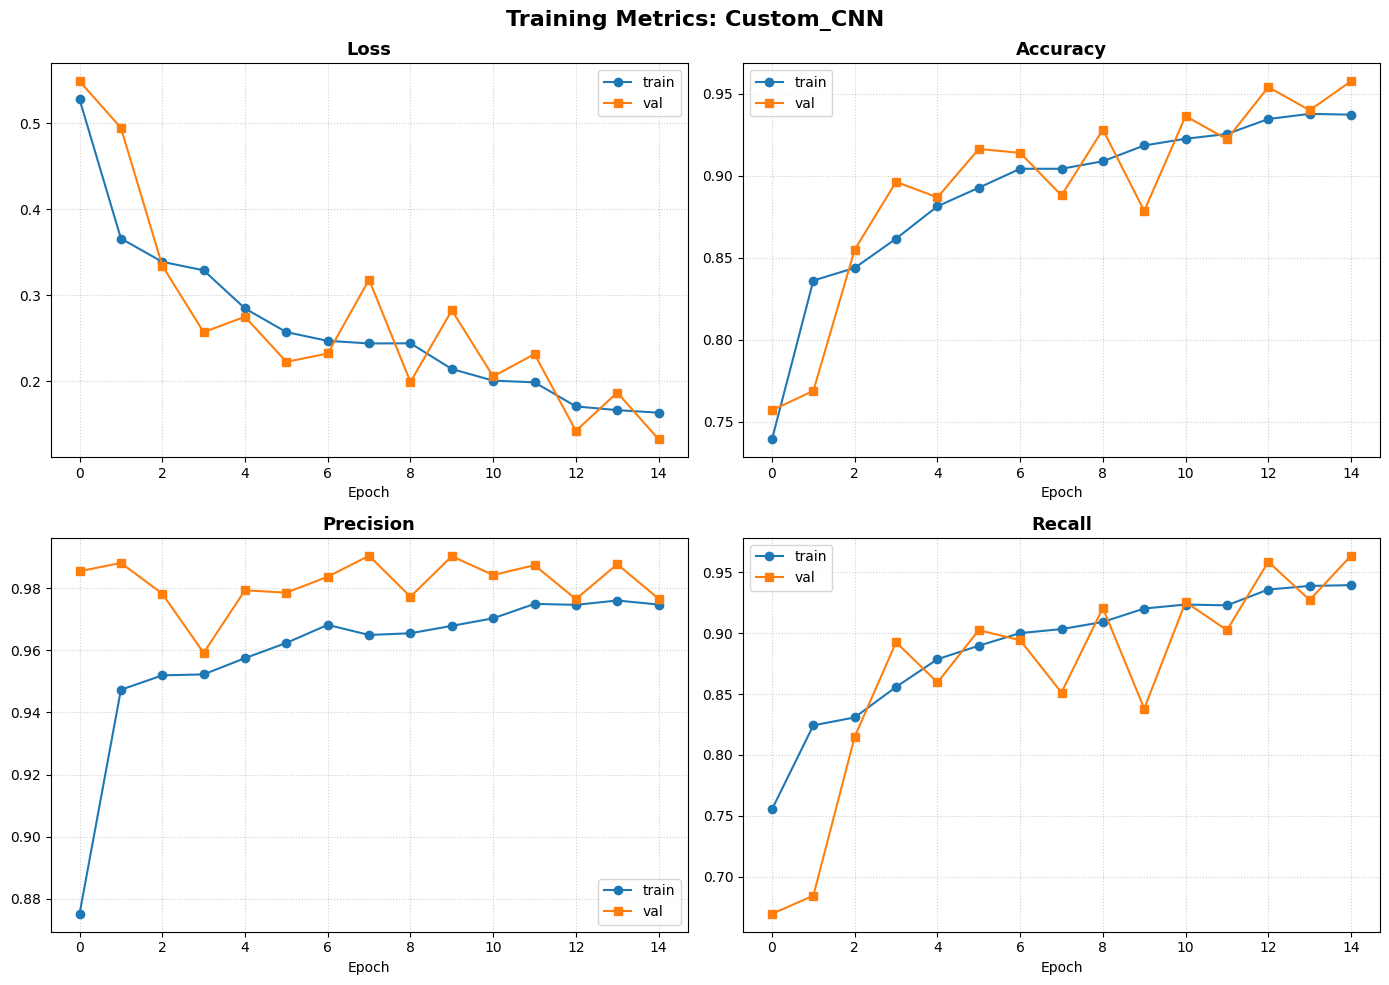

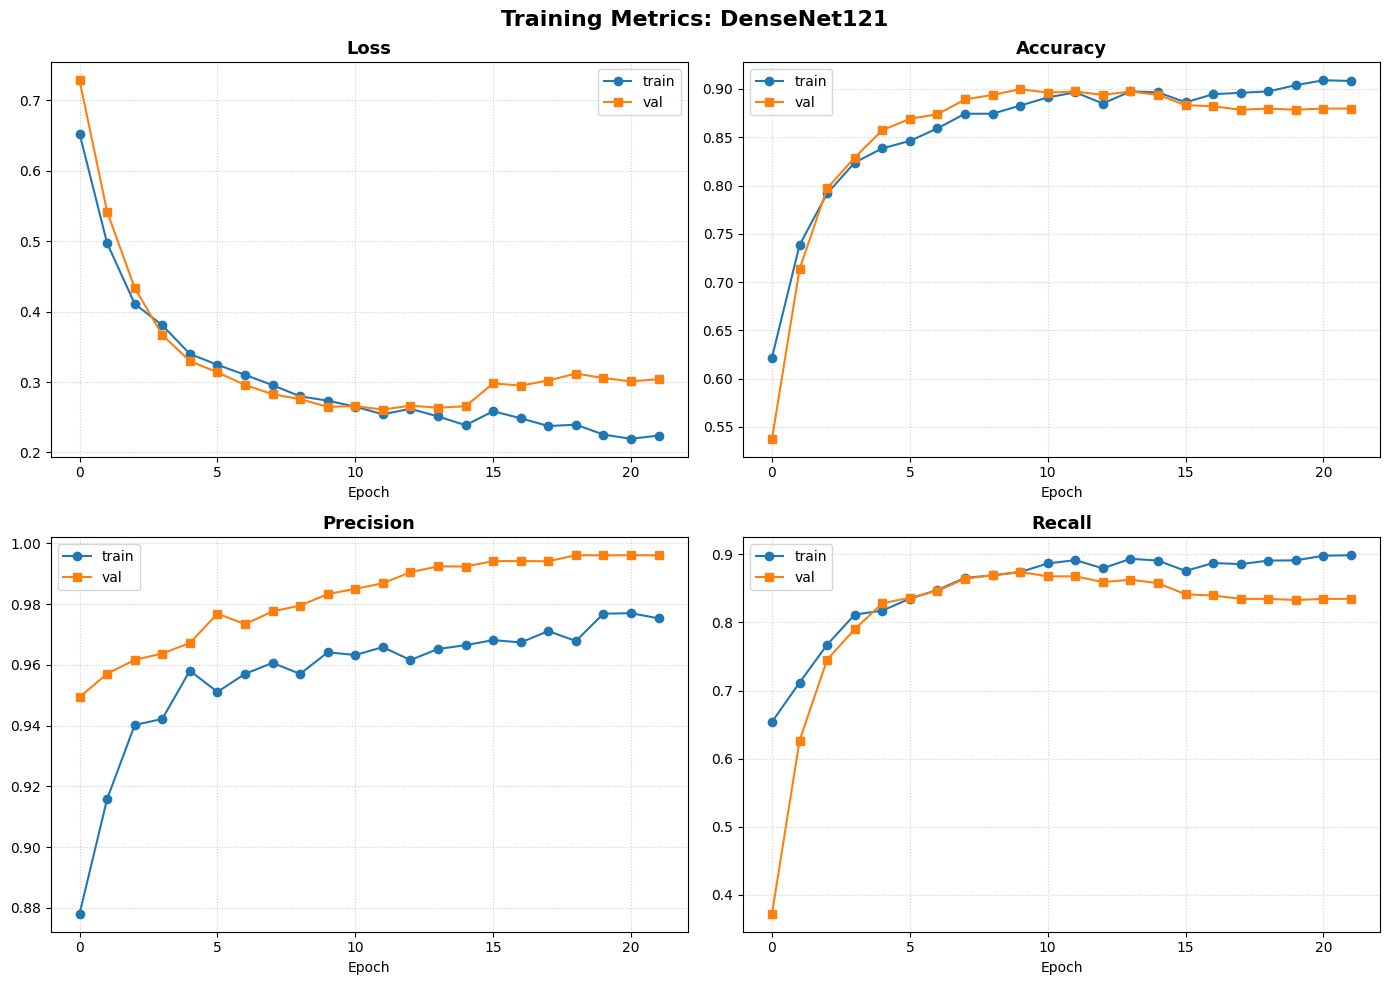

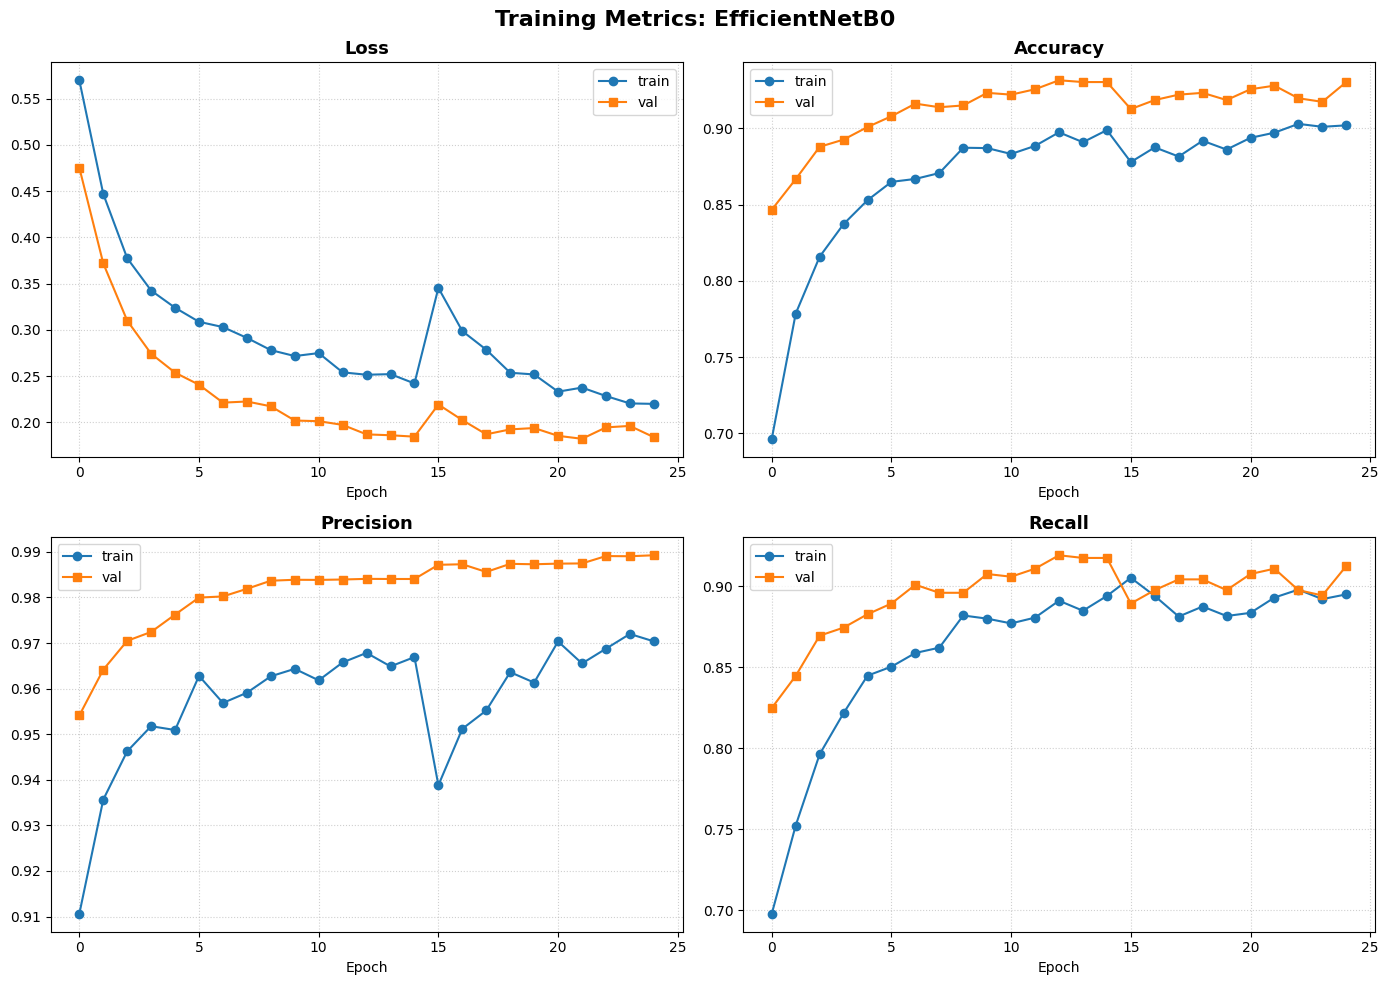

In [24]:
class MergedHistory:
    def __init__(self, history: Dict[str, list]) -> None:
        self.history = history


def merge_histories(*histories: tf.keras.callbacks.History) -> MergedHistory:
    merged: Dict[str, list] = {}
    for h in histories:
        for key, values in h.history.items():
            merged.setdefault(key, []).extend(values)
    return MergedHistory(merged)


def plot_learning_curves(history, model_name: str) -> None:
    metrics_to_plot = ['loss', 'accuracy', 'precision', 'recall']
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, metric in enumerate(metrics_to_plot):
        axes[i].plot(history.history[metric], label='train', marker='o')
        axes[i].plot(history.history[f'val_{metric}'], label='val', marker='s')
        axes[i].set_title(metric.capitalize(), fontsize=13, fontweight='bold')
        axes[i].set_xlabel('Epoch')
        axes[i].legend()
        axes[i].grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f'Training Metrics: {model_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f'{model_name}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_learning_curves(history_cnn, 'Custom_CNN')
plot_learning_curves(merge_histories(history_densenet, history_densenet_finetune), 'DenseNet121')
plot_learning_curves(merge_histories(history_efficientnet, history_efficientnet_finetune), 'EfficientNetB0')

## Quantitative Evaluation on Unseen Data (Test Set)


Custom_CNN
              precision    recall  f1-score   support

      Normal       0.92      0.95      0.94       258
   Pneumonia       0.98      0.96      0.97       595

    accuracy                           0.96       853
   macro avg       0.95      0.96      0.95       853
weighted avg       0.96      0.96      0.96       853

Specificity: 0.9535
ROC-AUC: 0.9889


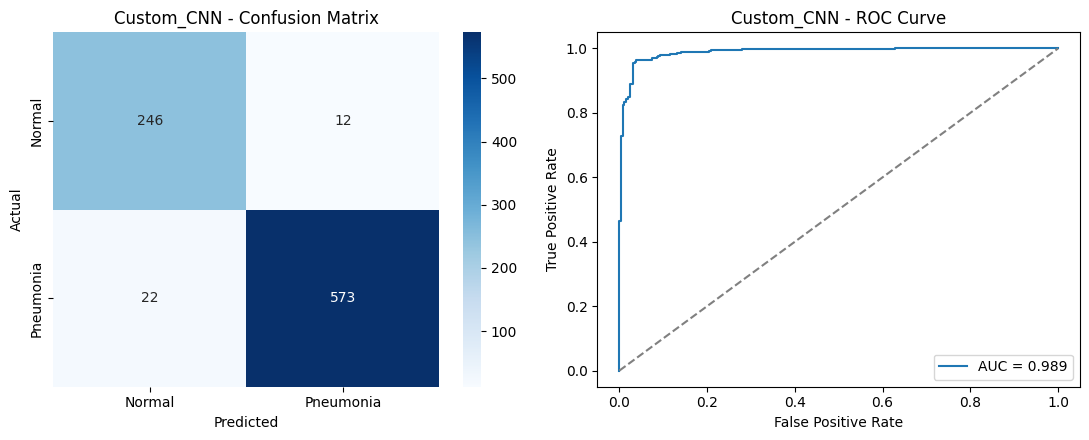


DenseNet121
              precision    recall  f1-score   support

      Normal       0.73      0.98      0.84       258
   Pneumonia       0.99      0.84      0.91       595

    accuracy                           0.88       853
   macro avg       0.86      0.91      0.87       853
weighted avg       0.91      0.88      0.89       853

Specificity: 0.9767
ROC-AUC: 0.9810


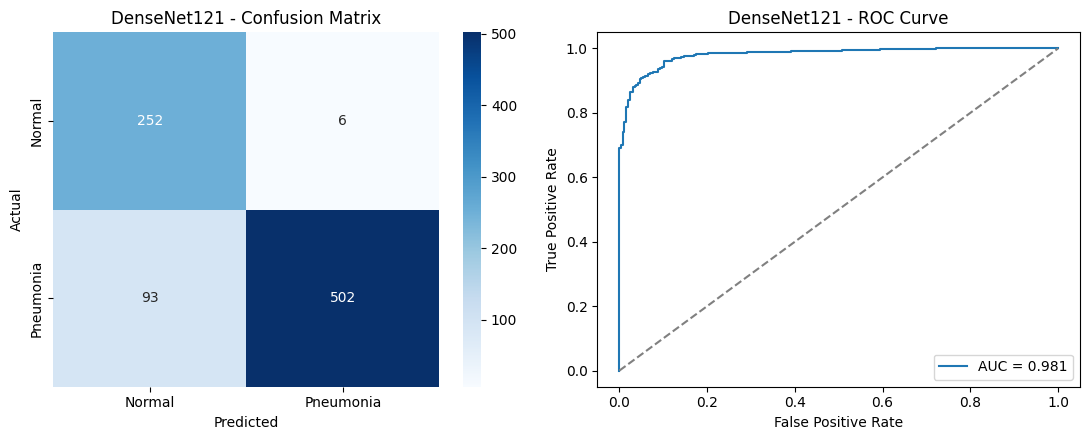


EfficientNetB0
              precision    recall  f1-score   support

      Normal       0.81      0.98      0.89       258
   Pneumonia       0.99      0.90      0.94       595

    accuracy                           0.92       853
   macro avg       0.90      0.94      0.91       853
weighted avg       0.93      0.92      0.93       853

Specificity: 0.9767
ROC-AUC: 0.9860


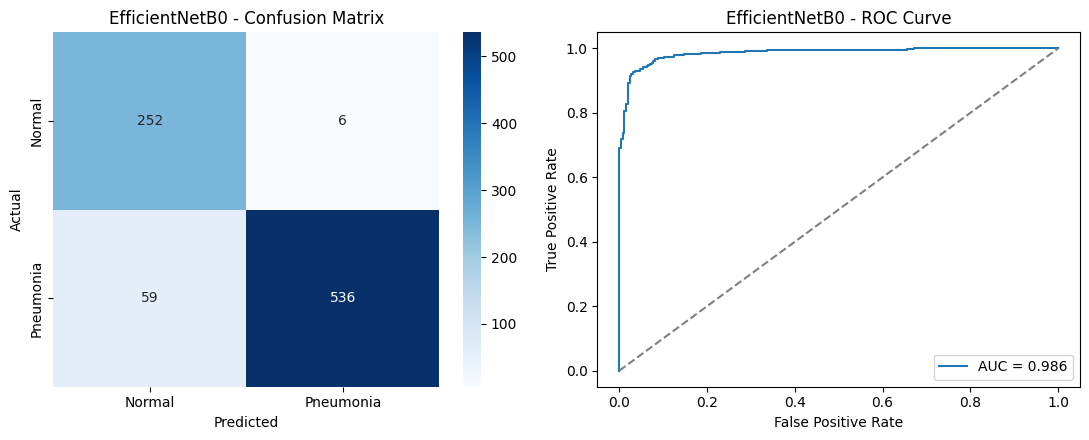

In [25]:
def evaluate_model(model: tf.keras.Model, test_ds, model_name: str, threshold: float = 0.5) -> Dict:
    y_true, y_prob = [], []
    for images, labels in test_ds:
        y_true.extend(labels.numpy().flatten())
        y_prob.extend(model.predict(images, verbose=0).flatten())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob > threshold).astype(int)

    print(f'\n{model_name}')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)
    roc_auc = roc_auc_score(y_true, y_prob)
    print(f'Specificity: {specificity:.4f}\nROC-AUC: {roc_auc:.4f}')
    

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'],
                yticklabels=['Normal', 'Pneumonia'], ax=axes[0])
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
    axes[0].set_title(f'{model_name} - Confusion Matrix')

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{model_name} - ROC Curve')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(RESULT_DIR / f'{model_name}_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'model': model_name,
        'accuracy': (tp + tn) / (tp + tn + fp + fn),
        'precision': tp / (tp + fp) if (tp + fp) else 0.0,
        'recall': tp / (tp + fn) if (tp + fn) else 0.0,
        'specificity': specificity,
        'f1': 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0.0,
        'roc_auc': roc_auc,
    }


all_results: List[Dict] = []
all_results.append(evaluate_model(model_cnn, test_dataset, 'Custom_CNN'))
all_results.append(evaluate_model(model_densenet, test_dataset, 'DenseNet121'))
all_results.append(evaluate_model(model_efficientnet, test_dataset, 'EfficientNetB0'))

## Comparison Table

In [26]:
df_comparison = pd.DataFrame(all_results)

df_comparison = df_comparison.sort_values('recall', ascending=False).reset_index(drop=True)
print(df_comparison.to_string(index=False))
df_comparison.to_csv(RESULT_DIR / 'comparison_table.csv', index=False)

best_model = df_comparison.iloc[0]
print(f"\nModel dengan recall (sensitivitas Pneumonia) tertinggi: {best_model['model']} ({best_model['recall']:.4f})")

         model  accuracy  precision   recall  specificity       f1  roc_auc
    Custom_CNN  0.960141   0.979487 0.963025     0.953488 0.971186 0.988874
EfficientNetB0  0.923798   0.988930 0.900840     0.976744 0.942832 0.985962
   DenseNet121  0.883939   0.988189 0.843697     0.976744 0.910245 0.980965

Model dengan recall (sensitivitas Pneumonia) tertinggi: Custom_CNN (0.9630)


# Export Model

In [27]:
model_lookup = {'Custom_CNN': model_cnn, 'DenseNet121': model_densenet, 'EfficientNetB0': model_efficientnet}
final_model = model_lookup[best_model['model']]

model_filename = "pneumonia_model.keras"
final_model.save(model_filename)

print(f"Model disimpan ke: {model_filename}")

Model disimpan ke: pneumonia_model.keras
